# Projeto Redes Neurais

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

Matplotlib is building the font cache; this may take a moment.


## Dados

In [85]:
def preencher_nulos_knn_onehot(df, n_vizinhos=5):
    """
    Preenche valores nulos em um DataFrame misto usando One-Hot Encoding e KNN.
    """
    df_temp = df.copy()

    cols_cat = df_temp.select_dtypes(
        include=["object", "category", "str"]
    ).columns.tolist()
    cols_num = df_temp.select_dtypes(
        exclude=["object", "category", "str"]
    ).columns.tolist()

    # PASSO 1: Aplicar One-Hot Encoding mantendo os NaNs
    dfs_dummies = []

    for col in cols_cat:
        dummy = pd.get_dummies(df_temp[col], prefix=col, dtype=float)
        dummy.loc[df_temp[col].isna(), :] = np.nan

        dfs_dummies.append(dummy)

    if dfs_dummies:
        df_encoded = pd.concat([df_temp[cols_num]] + dfs_dummies, axis=1)
    else:
        df_encoded = df_temp[cols_num]

    # PASSO 2: Aplicar o KNNImputer
    imputer = KNNImputer(n_neighbors=n_vizinhos)
    df_imputado = pd.DataFrame(
        imputer.fit_transform(df_encoded),
        columns=df_encoded.columns,
        index=df_encoded.index,
    )

    # PASSO 3: Reverter o One-Hot Encoding para o texto original
    df_final = df_imputado[cols_num].copy()

    for col in cols_cat:
        cols_dummy_da_vez = [c for c in df_imputado.columns if c.startswith(f"{col}_")]
        categoria_vencedora = df_imputado[cols_dummy_da_vez].idxmax(axis=1)
        df_final[col] = categoria_vencedora.str.replace(f"{col}_", "", regex=False)

    return df_final[df.columns]


def check_missing(df: pd.DataFrame):
    """
    Verifica valores ausentes em um DataFrame e imprime um relatório no console.
    """
    missing_counts = df.isnull().sum()
    missing_percentages = (df.isnull().sum() / len(df)) * 100

    missing_df = pd.DataFrame(
        {"Missing Count": missing_counts, "Percentage (%)": missing_percentages}
    )

    missing_df = missing_df[missing_df["Missing Count"] > 0]

    if missing_df.empty:
        print("No missing values found in the dataset!")
    else:
        missing_df = missing_df.sort_values(by="Percentage (%)", ascending=False)
        missing_df["Percentage (%)"] = missing_df["Percentage (%)"].round(2)

        print("\n--- Missing Values Report ---")
        print(missing_df.to_string())


def aplicar_label_encoding(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica Label Encoding em colunas categóricas de forma estrita.
    """
    df_encoded = df.copy()

    cols_cat = df_encoded.select_dtypes(
        include=["object", "category", "str"]
    ).columns.tolist()

    if not cols_cat:
        print("Nenhuma coluna categórica encontrada para aplicar Label Encoding.")
        return df_encoded

    for col in cols_cat:
        if df_encoded[col].isna().any():
            raise ValueError(
                f"ERRO: A coluna '{col}' contém valores nulos (NaN). "
                "O Label Encoding exige que os nulos sejam preenchidos antes desta etapa."
            )

        df_encoded[col] = df_encoded[col].astype("category").cat.codes

    return df_encoded


def normalizar_min_max(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica a normalização Min-Max (escala de 0 a 1) em TODAS as colunas numéricas.
    """
    df_norm = df.copy()

    cols_num = df_norm.select_dtypes(include=["number"]).columns.tolist()

    if not cols_num:
        print("Nenhuma coluna numérica encontrada para normalizar.")
        return df_norm

    scaler = MinMaxScaler()

    df_norm[cols_num] = scaler.fit_transform(df_norm[cols_num])

    return df_norm

def converter_para_imagens_2n(df: pd.DataFrame) -> np.ndarray:
    """
    Transforma um DataFrame tabular normalizado em um array de imagens 2N x 2N.
    
    Parâmetros:
    df (pd.DataFrame): DataFrame contendo apenas dados numéricos e normalizados (0 a 1).
    
    Retorna:
    np.ndarray: Array tridimensional contendo as imagens no formato (num_amostras, 2N, 2N).
    """
    # Converte o DataFrame para um array numpy para operações matemáticas mais rápidas
    dados = df.values
    num_amostras, n_features = dados.shape
    
    # Passo 1: O artigo especifica multiplicar por 255 para criar a escala de cinza
    dados_cinza = (dados * 255).astype(np.uint8)
    
    # Lista para armazenar todas as imagens geradas
    imagens_finais = []
    
    for linha in dados_cinza:
        # Passo 2: Construir a matriz N x N com duplicação e rotação (deslizamento)
        # O np.roll rotaciona o array. Usamos -i para mover para a esquerda.
        matriz_n = np.array([np.roll(linha, -i) for i in range(n_features)])
        
        # Passo 3: Expandir para 2N x 2N copiando a matriz N x N para os 4 quadrantes
        # O np.tile repete a matriz_n 2 vezes na vertical e 2 vezes na horizontal
        matriz_2n = np.tile(matriz_n, (2, 2))
        
        imagens_finais.append(matriz_2n)
        
    return np.array(imagens_finais)

def visualizar_imagens(imagens: np.ndarray, num_imagens: int = 5):
    """
    Plota as primeiras 'num_imagens' do array para visualização.
    
    Parâmetros:
    imagens (np.ndarray): O array de imagens retornado pela função de conversão.
    num_imagens (int): Quantidade de imagens a serem exibidas lado a lado.
    """
    num_imagens = min(num_imagens, len(imagens))
    
    fig, eixos = plt.subplots(1, num_imagens, figsize=(15, 5))
    
    if num_imagens == 1:
        eixos = [eixos]
        
    for i in range(num_imagens):
        eixos[i].imshow(imagens[i], cmap='gray', vmin=0, vmax=255)
        eixos[i].set_title(f"Amostra {i}")
        eixos[i].axis('off') 
        
    plt.tight_layout()
    plt.show()

datasets = {}


def relatorio_tecnico_desbalanceamento(df: pd.DataFrame, coluna_target: str):
    """
    Gera um relatório estatístico detalhado sobre o desbalanceamento da variável alvo,
    calculando frequências absolutas, relativas e o Imbalance Ratio (IR).
    """
    if coluna_target not in df.columns:
        raise KeyError(f"A coluna '{coluna_target}' não foi encontrada no DataFrame.")
        
    target_series = df[coluna_target].dropna()
    total_amostras = len(target_series)
    
    if total_amostras == 0:
        print("A coluna alvo está completamente vazia.")
        return

    contagens = target_series.value_counts()
    proporcoes = target_series.value_counts(normalize=True)
    
    classe_majoritaria = contagens.index[0]
    classe_minoritaria = contagens.index[-1]
    ir_score = contagens[classe_majoritaria] / contagens[classe_minoritaria]
    
    relatorio_df = pd.DataFrame({
        'Frequência Absoluta (N)': contagens,
        'Frequência Relativa (%)': (proporcoes * 100).round(2)
    })
    
    relatorio_df['Frequência Relativa (%)'] = relatorio_df['Frequência Relativa (%)'].map('{:.2f}%'.format)
    
    print("=" * 60)
    print(f"RELATÓRIO ESTATÍSTICO DE DISTRIBUIÇÃO DA CLASSE ALVO: '{coluna_target}'")
    print("=" * 60)
    print(f"Volume Total de Dados Válidos (N): {total_amostras}")
    print(f"Número de Classes Distintas:        {len(contagens)}")
    print("-" * 60)
    print(relatorio_df.to_string())
    print("-" * 60)
    print(f"Classe Majoritária: {classe_majoritaria} (N = {contagens[classe_majoritaria]})")
    print(f"Classe Minoritária: {classe_minoritaria} (N = {contagens[classe_minoritaria]})")
    print(f"Imbalance Ratio (IR): {ir_score:.2f}")
    
    print("Diagnóstico Técnico: ", end="")
    if ir_score == 1.0:
        print("Dataset perfeitamente balanceado (IR = 1.00).")
    elif ir_score <= 1.5:
        print("Equilíbrio estatístico aceitável (IR <= 1.50).")
    elif ir_score <= 4.0:
        print("Desbalanceamento moderado (1.50 < IR <= 4.00). Recomenda-se monitorar a métrica F1-Score.")
    else:
        print("Desbalanceamento severo (IR > 4.00). Risco alto de viés indutivo para a classe majoritária.")
    print("=" * 60)

### Adult Income

In [67]:
df = pd.read_csv("data/adult_income.csv")
df

,Unnamed: 0,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [68]:
df['target'] = df['target'].str.rstrip('.')

In [69]:
df = df.drop(columns=['Unnamed: 0', "fnlwgt", "education"])

check_missing(df)


--- Missing Values Report ---
                Missing Count  Percentage (%)
occupation                966            1.98
workclass                 963            1.97
native-country            274            0.56


In [70]:
df = preencher_nulos_knn_onehot(df)
check_missing(df)

No missing values found in the dataset!


In [71]:
df = aplicar_label_encoding(df)
df = normalizar_min_max(df)

In [72]:
df

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,0.301370,0.875,0.800000,0.666667,0.071429,0.2,1.00,1.0,0.021740,0.0,0.397959,0.951220,0.0
1,0.452055,0.750,0.800000,0.333333,0.285714,0.0,1.00,1.0,0.000000,0.0,0.122449,0.951220,0.0
2,0.287671,0.500,0.533333,0.000000,0.428571,0.2,1.00,1.0,0.000000,0.0,0.397959,0.951220,0.0
3,0.493151,0.500,0.400000,0.333333,0.428571,0.0,0.50,1.0,0.000000,0.0,0.397959,0.951220,0.0
4,0.150685,0.500,0.800000,0.333333,0.714286,1.0,0.50,0.0,0.000000,0.0,0.397959,0.121951,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.301370,0.500,0.800000,0.000000,0.714286,0.2,1.00,0.0,0.000000,0.0,0.357143,0.951220,0.0
48838,0.643836,0.500,0.533333,1.000000,0.571429,0.4,0.50,1.0,0.000000,0.0,0.397959,0.951220,0.0
48839,0.287671,0.500,0.800000,0.333333,0.714286,0.0,1.00,1.0,0.000000,0.0,0.500000,0.951220,0.0
48840,0.369863,0.500,0.800000,0.000000,0.071429,0.6,0.25,1.0,0.054551,0.0,0.397959,0.951220,0.0


In [86]:
relatorio_tecnico_desbalanceamento(df,"target")

RELATÓRIO ESTATÍSTICO DE DISTRIBUIÇÃO DA CLASSE ALVO: 'target'
Volume Total de Dados Válidos (N): 48842
Número de Classes Distintas:        2
------------------------------------------------------------
        Frequência Absoluta (N) Frequência Relativa (%)
target                                                 
0.0                       37155                  76.07%
1.0                       11687                  23.93%
------------------------------------------------------------
Classe Majoritária: 0.0 (N = 37155)
Classe Minoritária: 1.0 (N = 11687)
Imbalance Ratio (IR): 3.18
Diagnóstico Técnico: Desbalanceamento moderado (1.50 < IR <= 4.00). Recomenda-se monitorar a métrica F1-Score.


In [79]:
datasets["adult income"] = {"X":df.drop(columns=["target"]),"y":df['target'], "X_images":converter_para_imagens_2n(df.drop(columns=["target"]))}

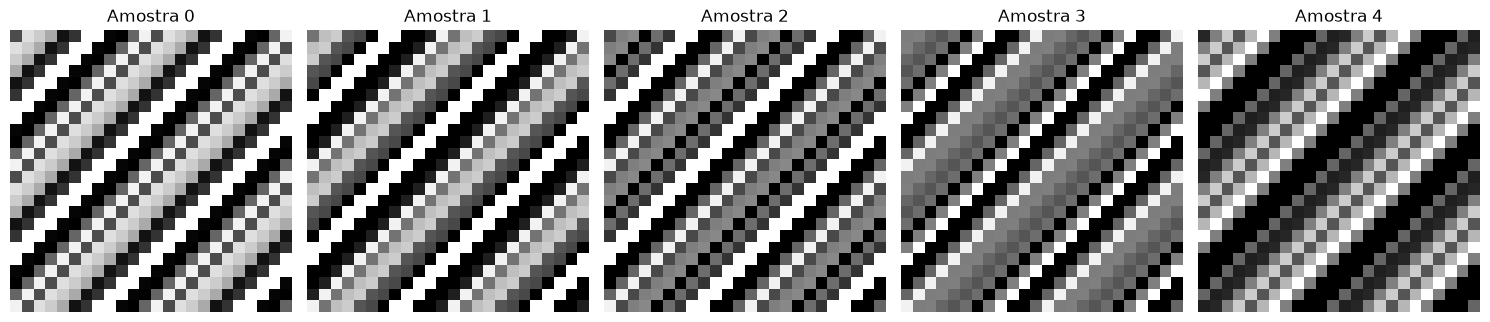

In [84]:
visualizar_imagens(datasets["adult income"]["X_images"], num_imagens=5)

## Treinamento